### LOADING CLEANED DATASET

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import re

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

from sklearn.preprocessing import StandardScaler, LabelEncoder

import json

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0})

df = pd.read_csv('../data/processed/cleaned_realdonaldtrump.csv')
content_series = df['content'].fillna("")
print(f"Dataset loaded successfully! Shape: {df.shape}")

Dataset loaded successfully! Shape: (43352, 14)


### NLP FEATURES ENGINEERING

In [83]:
# NOTE: We intentionally use the raw 'content' column here, not 'processed_content'.
# During preprocessing, URLs, mentions (@user), and special characters (#) are stripped
# to produce clean text for NLP vectorization. Therefore, structural features like
# hashtag/mention counts MUST be extracted from the original text before cleaning.
import textstat
from collections import Counter


df['exclamation_count'] = content_series.str.count('!')
df['question_count'] = content_series.str.count(r'\?')

df['capslock_words_count'] = content_series.str.findall(r'\b[A-Z]{2,}\b').str.len().fillna(0).astype(int)
df['word_count'] = content_series.str.split().str.len().fillna(0).astype(int)
df['sentence_count'] = content_series.str.count(r'[.!?]+').fillna(0).astype(int) + 1
df['char_count'] = content_series.str.len()
df['hashtag_count'] = content_series.str.count('#')
df['mention_count'] = content_series.str.count('@')
df["has_url"] = df["content"].str.contains(r'http\S+|www\.\S+|pic\.twitter\.com/\S+', regex=True).astype(int)
df["has_media_link"] = df["content"].str.contains(r'pic\.twitter\.com/\S+', regex=True).astype(int)
df["url_count"] = df["content"].str.count(r'http\S+|www\.\S+|pic\.twitter\.com/\S+')


df["exclamation_per_word"] = df["exclamation_count"] / (df["word_count"] + 1)
df["question_per_word"] = df["question_count"] / (df["word_count"] + 1)
df["ends_with_exclamation"] = content_series.str.rstrip().str.endswith("!").astype(int)
df["ends_with_question"] = content_series.str.rstrip().str.endswith("?").astype(int)

# Maximum run of consecutive exclamation marks
df["max_exclamation_run"] = content_series.str.findall(r'!+').apply(lambda runs: max(map(len, runs)) if runs else 0)

FIRST_PERSON_SINGULAR = {"i", "me", "my", "mine"}
FIRST_PERSON_PLURAL = {"we", "us", "our", "ours"}
SECOND_PERSON = {"you", "your", "yours"}
MODALS = {"will", "would", "can", "could", "must", "should"}
NEGATIONS = {"no", "not", "nor", "never"}


def count_words_in_set(text, words):
    tokens = str(text).split()
    return sum(token in words for token in tokens)

df["first_person_singular_count"] = df["processed_content"].apply(lambda x: count_words_in_set(x, FIRST_PERSON_SINGULAR))
df["first_person_plural_count"] = df["processed_content"].apply(lambda x: count_words_in_set(x, FIRST_PERSON_PLURAL))
df["second_person_count"] = df["processed_content"].apply(lambda x: count_words_in_set(x, SECOND_PERSON))
df["modal_count"] = df["processed_content"].apply(lambda x: count_words_in_set(x, MODALS))
df["negation_count"] = df["processed_content"].apply(lambda x: count_words_in_set(x, NEGATIONS))


EMPHATICS = {
    "always", "never", "definitely", "obviously",
    "totally", "really", "very", "strongly", "completely",
    "absolutely", "altogether", "amazingly", "astonishingly",
    "awfully", "considerably", "decidedly", "deeply",
    "dramatically", "enormously", "entirely", "especially",
    "exceptionally", "exceedingly", "extremely", "extraordinarily",
    "fairly", "fully", "greatly", "highly", "hugely",
    "immensely", "incredibly", "intensely", "markedly",
    "massively", "particularly", "profoundly", "remarkably",
    "seriously", "significantly", "substantially", "supremely",
    "tremendously", "truly", "utterly", "vastly",
    "actually", "basically", "completely", "crazy", "deeply",
    "especially", "genuinely", "insanely", "literally",
    "majorly", "mega", "pretty", "quite",
    "ridiculously", "so", "super", "terribly",
    "too", "unbelievably", "unusually", "wildly",
    "categorically", "entirely", "fundamentally", "inherently",
    "overwhelmingly", "perfectly", "positively", "purely",
    "radically", "strictly", "thoroughly", "unconditionally",
    "unequivocally", "universally", "wholly"
}

CERTAINTY_WORDS = {
    "certainly", "definitely", "undoubtedly", "surely",
    "clearly", "obviously", "unquestionably",
    "absolutely", "assuredly", "categorically", "decidedly",
    "evidently", "explicitly", "firmly", "inevitably",
    "indisputably", "indubitably", "incontestably", "indeed",
    "inevitably", "manifestly", "necessarily", "plainly",
    "positively", "precisely", "surely", "unambiguously",
    "undeniably", "unmistakably", "unquestionably",
    "unequivocally", "withoutdoubt",
    "certain", "confident", "conclusive", "definite",
    "indisputable", "inevitable", "obvious", "proven",
    "sure", "undeniable", "unmistakable", "verified",
    "all", "any", "every", "everyone", "everything",
    "none", "nothing", "nobody", "noone"
}

SUPERLATIVES = {
    "best", "greatest", "biggest", "strongest",
    "worst", "lowest", "highest",
    "amazing", "brilliant", "finest", "greatest",
    "ideal", "leading", "optimal", "outstanding",
    "perfect", "premier", "superior", "ultimate",
    "unmatched", "unparalleled", "unrivaled",
    "biggest", "largest", "longest", "most",
    "maximum", "maximum", "smallest", "tallest",
    "widest", "youngest", "oldest",
    "dominant", "foremost", "main", "major",
    "mostimportant", "powerful", "primary",
    "strongest", "supreme", "top",
    "awfullest", "lowest", "poorest", "smallest",
    "terrible", "ugliest", "weakest", "worst",
    "absolute", "alltime", "ever", "numberone",
    "recordbreaking", "toprated", "worldclass"
}

NEGATIVE_EMPHATICS = {
    "terrible", "horrible", "awful", "disaster",
    "disastrous", "catastrophic", "unacceptable",
    "abhorrent", "appalling", "atrocious", "deplorable",
    "dreadful", "embarrassing", "frightening", "ghastly",
    "heinous", "hideous", "intolerable", "ludicrous",
    "miserable", "monstrous", "outrageous", "pathetic",
    "repulsive", "revolting", "shameful", "shocking",
    "sickening", "tragic", "unbearable", "unforgivable",
    "unjustifiable", "unthinkable", "vile", "wretched",
    "broken", "chaotic", "corrupt", "defective",
    "dysfunctional", "failed", "failure", "flawed",
    "incompetent", "inferior", "misguided", "poor",
    "reckless", "ruined", "useless", "worthless",
    "calamity", "collapse", "crisis", "devastating",
    "devastation", "hazardous", "nightmare", "ruin",
    "shambles", "tragedy", "unsafe", "waste",
    "abysmal", "disgusting", "garbage", "insane",
    "ridiculous", "rotten", "stupid", "toxic",
    "trash", "useless"
}
TRUMP_EMPHATICS = {
    "tremendous",
    "tremendously",
    "incredible",
    "incredibly",
    "beautiful",
    "fantastic",
    "unbelievable",
    "huge",
    "massive",
    "major",
    "totally",
    "highly",
    "really",
    "very",
    "strong",
    "strongly",
    "great",
    "big",
    "biggest",
    "historic",
    "record",
    "recordbreaking",
    "powerful",
    "successful",
}

TRUMP_CERTAINTY_WORDS = {
    "will",
    "must",
    "cannot",
    "never",
    "always",
    "nobody",
    "everyone",
    "nothing",
    "everything",
    "proven",
    "fact",
    "facts",
    "truth",
    "true",
    "clear",
    "certain",
    "sure",
    "obvious",
}

TRUMP_SUPERLATIVES = {
    "greatest",
    "best",
    "biggest",
    "strongest",
    "highest",
    "lowest",
    "largest",
    "most",
    "top",
    "numberone",
    "unmatched",
    "unprecedented",
    "historic",
    "phenomenal",
    "tremendous",
    "incredible",
    "beautiful",
    "perfect",
    "total",
    "complete",
}

TRUMP_NEGATIVE_EMPHATICS = {
    "fake",
    "failing",
    "crooked",
    "sleepy",
    "weak",
    "badly",
    "dumb",
    "crazy",
    "dishonest",
    "corrupt",
    "incompetent",
    "disgrace",
    "hoax",
    "rigged",
    "fraud",
    "scam",
    "phony",
    "radical",
    "extremist",
    "pathetic",
    "sad",
    "terrible",
    "disaster",
    "failed",
    "loser",
    "losers",
    "enemy",
    "witchhunt",
}

EMPHATICS.update(TRUMP_EMPHATICS)
CERTAINTY_WORDS.update(TRUMP_CERTAINTY_WORDS)
SUPERLATIVES.update(TRUMP_SUPERLATIVES)
NEGATIVE_EMPHATICS.update(TRUMP_NEGATIVE_EMPHATICS)

df["emphatic_word_count"] = df["processed_content"].apply(lambda x: count_words_in_set(x, EMPHATICS))
df["certainty_word_count"] = df["processed_content"].apply(lambda x: count_words_in_set(x, CERTAINTY_WORDS))
df["superlative_word_count"] = df["processed_content"].apply(lambda x: count_words_in_set(x, SUPERLATIVES))
df["negative_emphatic_word_count"] = df["processed_content"].apply(lambda x: count_words_in_set(x, NEGATIVE_EMPHATICS))

df["cleaned_content"] = df["cleaned_content"].fillna("")
df["avg_word_length"] = df["cleaned_content"].apply(lambda text: np.mean([len(word) for word in text.split()]) if text.split() else 0)
df["avg_sentence_length"] = df["cleaned_content"].apply(lambda text: np.mean([len(sentence.split()) for sentence in re.split(r'[.!?]', text) if sentence.strip()]) if text.strip() else 0)

# Readability score using Flesch Reading Ease formula
df["flesch_reading_ease"] = df["content"].apply(lambda text: textstat.flesch_reading_ease(str(text)))
# Readability score using Flesch-Kincaid Grade Level formula
df["flesch_kincaid_grade"] = df["content"].apply(lambda text: textstat.flesch_kincaid_grade(str(text)))

def repetition_ratio(text):
    tokens = str(text).split()
    if not tokens:
        return 0.0

    counts = Counter(tokens)
    repeated = sum(count - 1 for count in counts.values() if count > 1)

    return repeated / len(tokens)

# Proportion of repeated words to total words
df["repetition_ratio"] = df["processed_content"].apply(repetition_ratio)

# Shouting index: ratio of capital letters to total characters
df['shouting_index'] = content_series.str.findall(r'[A-Z]').str.len() / (df['char_count'] + 1)

def calculate_ttr(text: str) -> float:
    """
    Calculate Type-Token Ratio (TTR) for a given text. TTR = (Number of Unique Words) / (Total Number of Words).
    """
    tokens = str(text).split()
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

df['lexical_diversity_ttr'] = df['cleaned_content'].apply(calculate_ttr)
df['has_hashtag'] = df['has_hashtag'].fillna(0).astype(int)
df['has_mention'] = df['has_mention'].fillna(0).astype(int)

print("Basic features extracted!")

Basic features extracted!


### VISUALIZATION: DISTRIBUTIONS OF ENGINEERED TEXT FEATURES

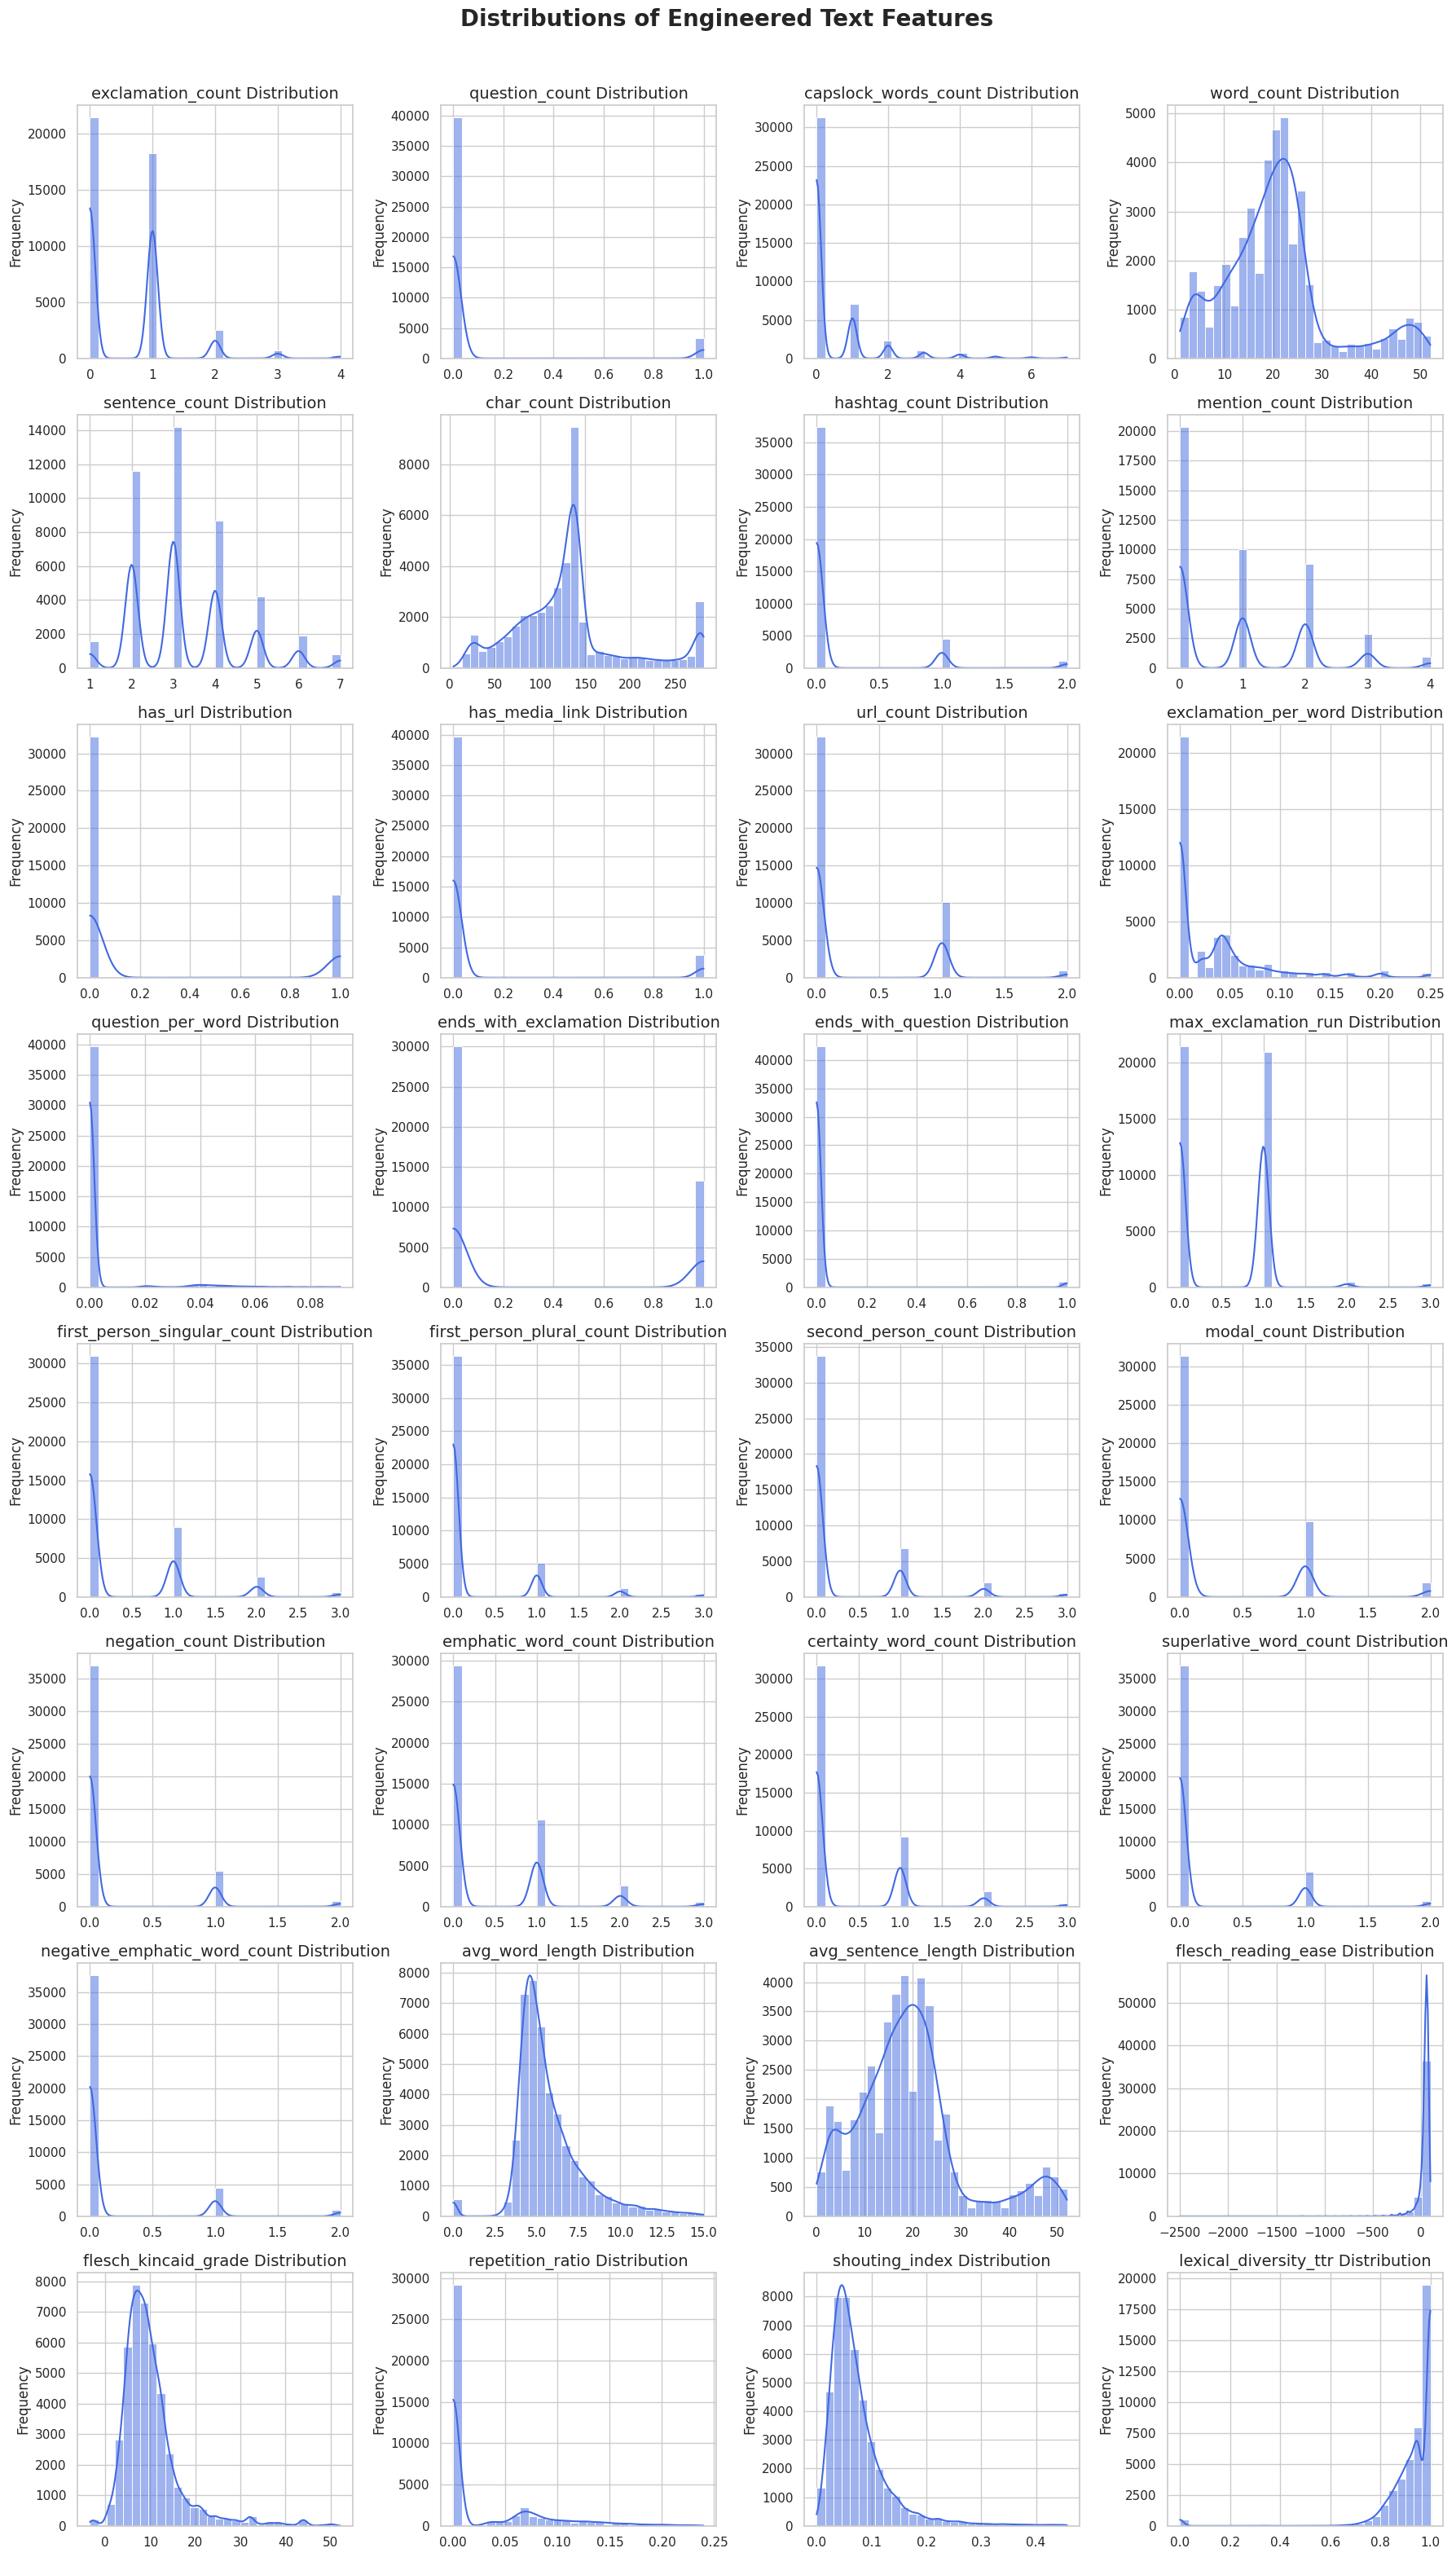

In [84]:
import math

features_to_plot = [
    "exclamation_count",
    "question_count",
    "capslock_words_count",
    "word_count",
    "sentence_count",
    "char_count",
    "hashtag_count",
    "mention_count",
    "has_url",
    "has_media_link",
    "url_count",
    "exclamation_per_word",
    "question_per_word",
    "ends_with_exclamation",
    "ends_with_question",
    "max_exclamation_run",
    "first_person_singular_count",
    "first_person_plural_count",
    "second_person_count",
    "modal_count",
    "negation_count",
    "emphatic_word_count",
    "certainty_word_count",
    "superlative_word_count",
    "negative_emphatic_word_count",
    "avg_word_length",
    "avg_sentence_length",
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "repetition_ratio",
    "shouting_index",
    "lexical_diversity_ttr",
]

n_cols = 4
n_rows = math.ceil(len(features_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
fig.suptitle('Distributions of Engineered Text Features', fontsize=20, fontweight='bold')

for i, feature in enumerate(features_to_plot):
    row, col = divmod(i, n_cols)
    max_val = df[feature].quantile(0.99)
    filtered_data = df[df[feature] <= max_val][feature]

    sns.histplot(filtered_data, bins=30, ax=axes[row, col], color='royalblue', kde=True)
    axes[row, col].set_title(f'{feature} Distribution', fontsize=14)
    axes[row, col].set_xlabel('')
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### NUMERIC TOKEN ANALYSIS

Tweets with any number:   13,118 (30.3%)
Tweets with year mention: 1,339 (3.1%)
Tweets with large number: 93 (0.2%)


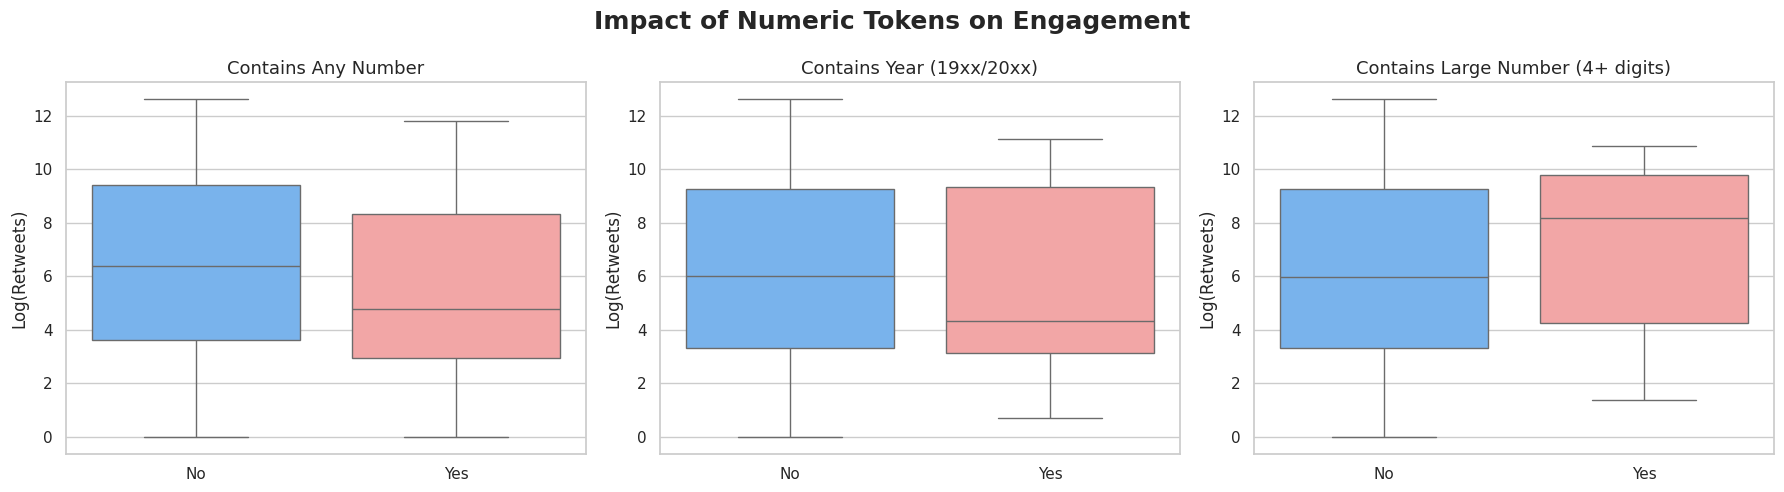

Numeric token features extracted!


In [85]:
# Digits were preserved during cleaning (regex [^a-z0-9\s]) to retain contextual
# numbers like years (2020), quantities (100), and percentages.
# Here we analyze whether tweets containing numbers show different engagement.

df['has_number'] = df['cleaned_content'].str.contains(r'\d+', regex=True).astype(int)
df['number_token_count'] = df['cleaned_content'].str.findall(r'\b\d+\b').str.len().fillna(0).astype(int)
df['has_year_mention'] = df['cleaned_content'].str.contains(r'\b(?:19|20)\d{2}\b', regex=True).astype(int)
df['has_large_number'] = df['cleaned_content'].str.contains(r'\b(?!(?:19|20)\d{2})\d{4,}\b', regex=True).astype(int)

print(f"Tweets with any number:   {df['has_number'].sum():,} ({df['has_number'].mean()*100:.1f}%)")
print(f"Tweets with year mention: {df['has_year_mention'].sum():,} ({df['has_year_mention'].mean()*100:.1f}%)")
print(f"Tweets with large number: {df['has_large_number'].sum():,} ({df['has_large_number'].mean()*100:.1f}%)")

# Visualization: engagement by numeric content
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impact of Numeric Tokens on Engagement', fontsize=18, fontweight='bold')

log_rt = np.log1p(df['retweets'])

for ax, col, label in zip(axes,
                           ['has_number', 'has_year_mention', 'has_large_number'],
                           ['Contains Any Number', 'Contains Year (19xx/20xx)', 'Contains Large Number (4+ digits)']):
    sns.boxplot(x=df[col].map({0: 'No', 1: 'Yes'}), y=log_rt,
                palette=['#66b3ff', '#ff9999'], ax=ax, hue=df[col].map({0: 'No', 1: 'Yes'}), legend=False)
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Log(Retweets)')

plt.tight_layout()
plt.show()

print("Numeric token features extracted!")

### SENTIMENT ANALYSIS - VADER (Valence Aware Dictionary and sEntiment Reasoner)

In [86]:
nltk.download("vader_lexicon", quiet=True)

sia = SentimentIntensityAnalyzer()

VADER_COLUMNS = [
    "sent_vader_neg",
    "sent_vader_neu",
    "sent_vader_pos",
    "sent_vader_compound",
    "sentiment_category",
    "sentiment_intensity",
]


def clean_for_vader(text: object) -> str:
    """
    Remove structural metadata that should not affect lexical sentiment.
    Keep punctuation, capitalization, emoji, and emoticons because VADER uses them.
    """
    if not isinstance(text, str):
        return ""

    text = re.sub(r"https?://\S+|www\.\S+|pic\.twitter\.com/\S+", " ", text)
    text = re.sub(r"@ \w+", " ", text)
    text = re.sub(r"# \w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def get_vader_scores(text: object) -> dict[str, float]:
    """
    Return VADER neg/neu/pos/compound scores.
    Empty or invalid input is represented as neutral sentiment.
    """
    if not isinstance(text, str) or not text.strip():
        return {
            "neg": 0.0,
            "neu": 1.0,
            "pos": 0.0,
            "compound": 0.0,
        }

    return sia.polarity_scores(text)

# Remove old VADER-derived columns before recalculating them.
df = df.drop(columns=[col for col in VADER_COLUMNS if col in df.columns])

# Calculate scores once per row.
vader_scores = (
    df["content"]
    .map(clean_for_vader)
    .map(get_vader_scores)
    .apply(pd.Series)
    .rename(
        columns={
            "neg": "sent_vader_neg",
            "neu": "sent_vader_neu",
            "pos": "sent_vader_pos",
            "compound": "sent_vader_compound",
        }
    )
)

# reruns overwrite values instead of duplicating columns.
df["sent_vader_neg"] = pd.to_numeric(vader_scores["sent_vader_neg"], errors="coerce").fillna(0.0)
df["sent_vader_neu"] = pd.to_numeric(vader_scores["sent_vader_neu"], errors="coerce").fillna(1.0)
df["sent_vader_pos"] = pd.to_numeric(vader_scores["sent_vader_pos"], errors="coerce").fillna(0.0)
df["sent_vader_compound"] = pd.to_numeric(vader_scores["sent_vader_compound"], errors="coerce").fillna(0.0)

compound = df["sent_vader_compound"]

df["sentiment_category"] = np.select([compound.ge(0.05), compound.le(-0.05),],["Positive","Negative",],default="Neutral",)

df["sentiment_intensity"] = compound.abs()

print("Sentiment analysis complete!")
df_sample = df[VADER_COLUMNS].sample(n=5)
display(df_sample)

Sentiment analysis complete!


,sent_vader_neg,sent_vader_neu,sent_vader_pos,sent_vader_compound,sentiment_category,sentiment_intensity
21098,0.000,0.773,0.227,0.6249,Positive,0.6249
4939,0.000,1.000,0.000,0.0000,Neutral,0.0000
8552,0.000,1.000,0.000,0.0000,Neutral,0.0000
38162,0.083,0.866,0.050,-0.3869,Negative,0.3869
20749,0.461,0.539,0.000,-0.7177,Negative,0.7177


### VISUALIZATION: SENTIMENT AND ENGAGEMENT

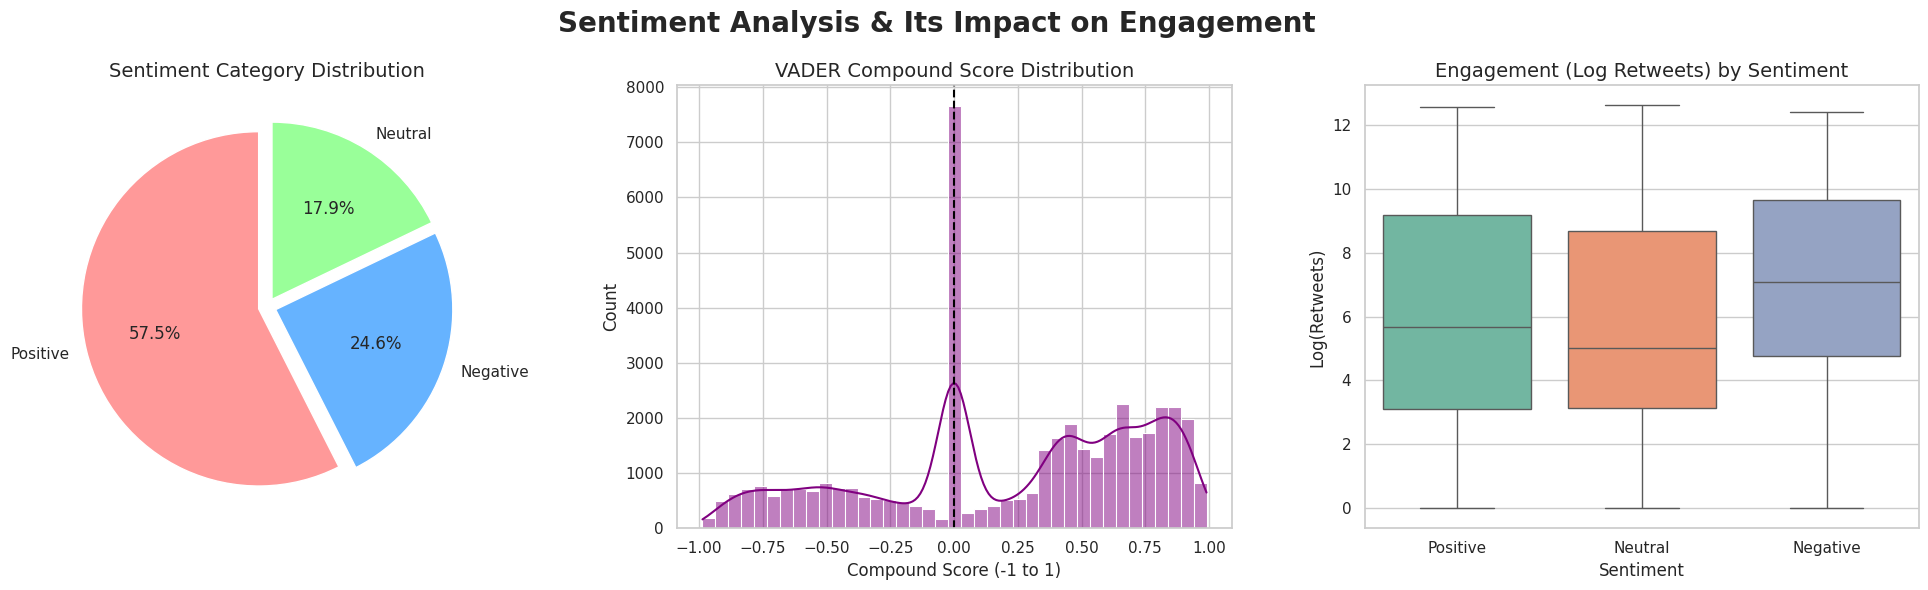

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Sentiment Analysis & Its Impact on Engagement', fontsize=20, fontweight='bold')

sentiment_counts = df['sentiment_category'].value_counts()
axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=90, explode=(0.05, 0.05, 0.05))
axes[0].set_title('Sentiment Category Distribution', fontsize=14)

sns.histplot(df['sent_vader_compound'], bins=39, color='purple', kde=True, ax=axes[1])
axes[1].axvline(x=0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_title('VADER Compound Score Distribution', fontsize=14)
axes[1].set_xlabel('Compound Score (-1 to 1)')

df['log_retweets'] = np.log1p(df['retweets'])

sns.boxplot(x='sentiment_category', y='log_retweets', data=df, palette='Set2', ax=axes[2], hue='sentiment_category', legend=False)

axes[2].set_title('Engagement (Log Retweets) by Sentiment', fontsize=14)
axes[2].set_ylabel('Log(Retweets)')
axes[2].set_xlabel('Sentiment')

plt.tight_layout()
plt.show()

### TEXT REPRESENTATION:
- CountVectorizer - converts text to the vector using simple Bag of Words where each columns is the unique word
- TF-IDF (Term Frequency - Inverse Document Frequency) - similar to CountVectorizer but adds weight
    - TF — Term Frequency: how often word appears in the single text
    - IDF — Inverse Document Frequency: how rare is the word in the whole corpus of texts
- LDA (Latent Dirichlet Allocation) - is a generative probabilistic model that assumes documents are mixtures of topics, and topics are mixtures of words. It discovers latent topics in the corpus based on word co-occurrence patterns.

In [88]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

MAX_FEATURES = 10000 # Limit vocabulary size for vectorizers to top 10k terms by frequency
N_TOPICS = 5 # Number of LDA topics to extract

# Full corpus, aligned with full df
corpus = df["processed_content"].fillna("")

# CountVectorizer: raw term counts, include unigrams and bigrams
count_vec = CountVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2), # to include bigrams like "not good"
    min_df=5,
    max_df=0.95
)

X_count = count_vec.fit_transform(corpus)
print(f"CountVectorizer matrix shape: {X_count.shape}")

# TF-IDF: weighted word/bigram representation
tfidf_vec = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

X_tfidf = tfidf_vec.fit_transform(corpus)
print(f"TF-IDF matrix shape: {X_tfidf.shape}")

# LDA Topic Modeling fitted on raw count features from CountVectorizer
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42
)

X_topics = lda.fit_transform(X_count)
print(f"LDA topic matrix shape: {X_topics.shape}")

for i in range(N_TOPICS):
    df[f"topic_lda_{i+1}"] = X_topics[:, i]

# Print topic keywords
feature_names = count_vec.get_feature_names_out()

for topic_idx, topic_weights in enumerate(lda.components_):
    top_indices = topic_weights.argsort()[-15:][::-1]
    top_terms = [feature_names[i] for i in top_indices]

    print(f"Topic {topic_idx + 1}:")
    print(", ".join(top_terms))
    print()

print("Text representation complete!")

CountVectorizer matrix shape: (43352, 10000)
TF-IDF matrix shape: (43352, 10000)
LDA topic matrix shape: (43352, 5)
Topic 1:
he, his, great, will, job, our, me, mentions_barackobama, my, him, obama, not, people, should, total

Topic 2:
will, we, our, country, great, year, our country, china, they, america, american, not, job, deal, get

Topic 3:
you, mentions_realdonaldtrump, trump, thank, thank you, great, thanks, your, donald, president, donald trump, my, run, need, can

Topic 4:
not, they, democrat, can, time, you, republican, obama, want, people, no, president, nothing, good, will

Topic 5:
my, they, great, news, fake, no, hillary, medium, me, she, trump, fake news, poll, her, big

Text representation complete!


### VISUALIZATION: LDA TOPIC MODELING

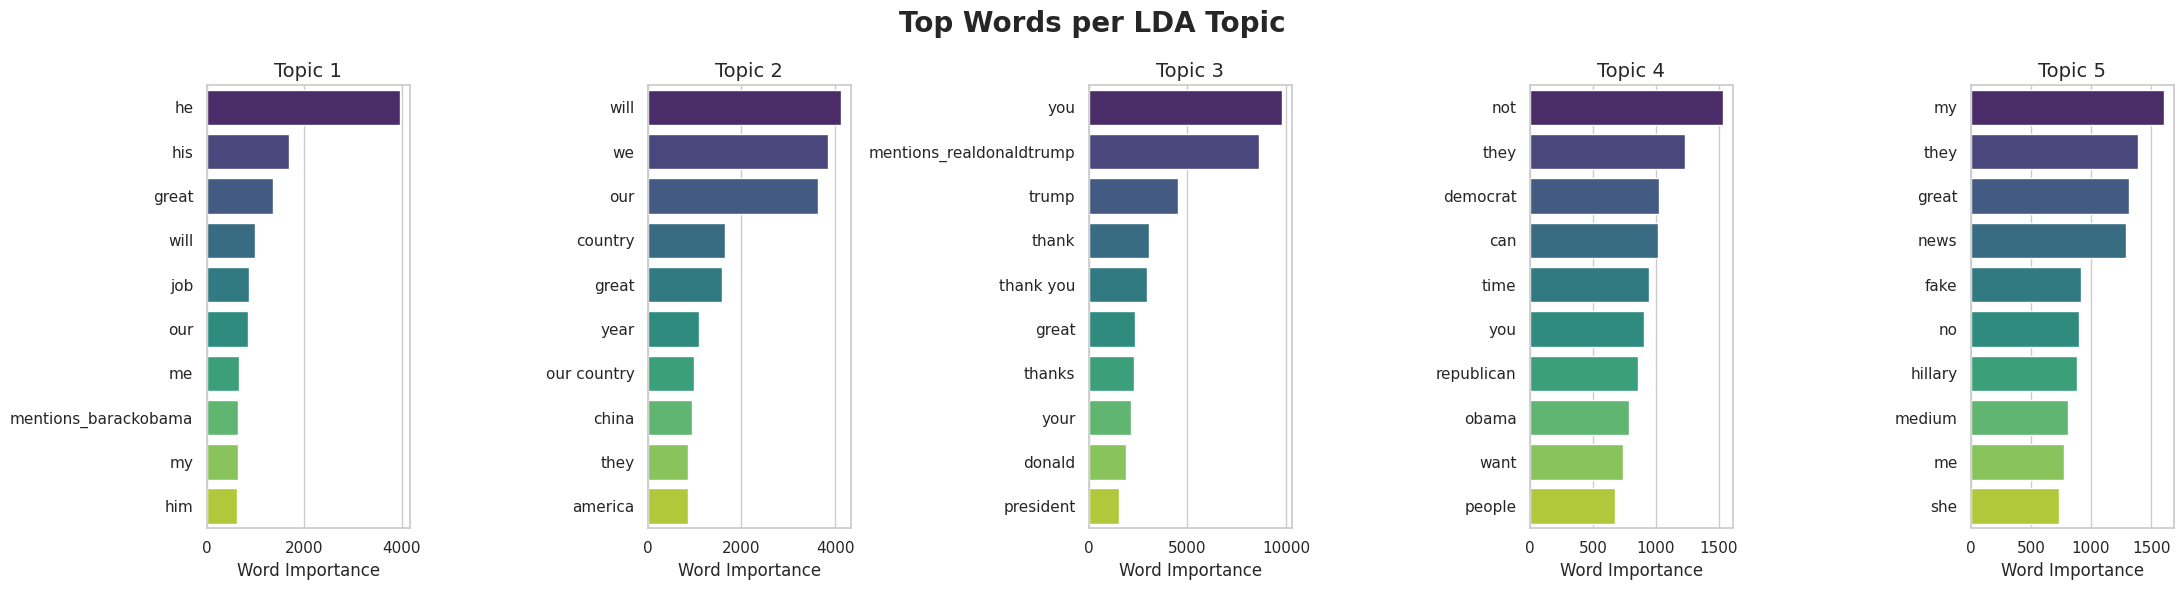

In [89]:
lda_feature_names = tfidf_vec.get_feature_names_out()

fig, axes = plt.subplots(1, N_TOPICS, figsize=(22, 6), sharey=False)
fig.suptitle('Top Words per LDA Topic', fontsize=20, fontweight='bold')

for topic_idx, topic in enumerate(lda.components_):
    top_features_ind = topic.argsort()[:-11:-1]
    top_features = [lda_feature_names[i] for i in top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]
    sns.barplot(x=weights, y=top_features, ax=ax, palette='viridis', hue=top_features, legend=False)
    ax.set_title(f'Topic {topic_idx + 1}', fontsize=14)
    ax.set_xlabel('Word Importance')

plt.tight_layout()
plt.show()

### VISUALIZATION: CORRELATION HEATMAP

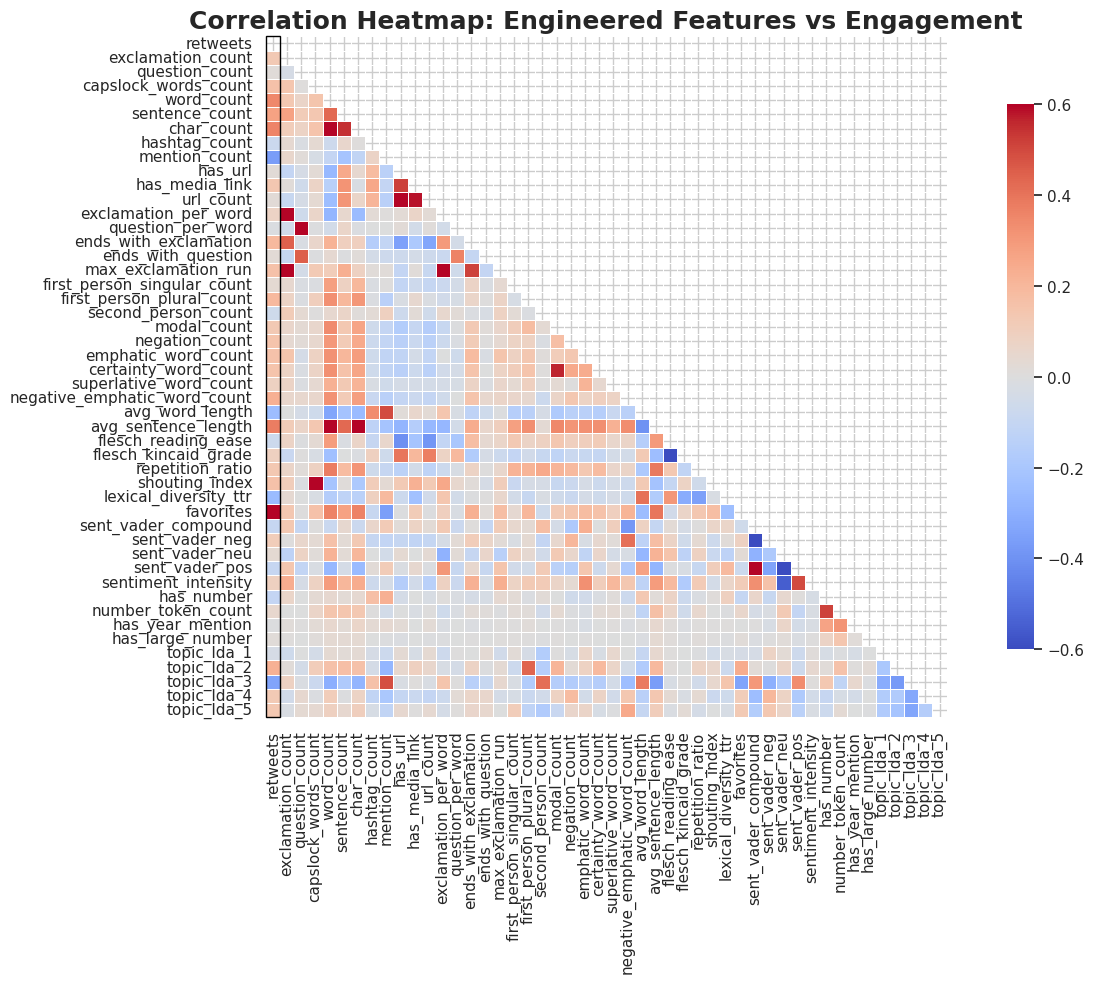

In [90]:
from matplotlib.patches import Rectangle


numeric_cols = [
    'retweets',
    "exclamation_count",
    "question_count",
    "capslock_words_count",
    "word_count",
    "sentence_count",
    "char_count",
    "hashtag_count",
    "mention_count",
    "has_url",
    "has_media_link",
    "url_count",
    "exclamation_per_word",
    "question_per_word",
    "ends_with_exclamation",
    "ends_with_question",
    "max_exclamation_run",
    "first_person_singular_count",
    "first_person_plural_count",
    "second_person_count",
    "modal_count",
    "negation_count",
    "emphatic_word_count",
    "certainty_word_count",
    "superlative_word_count",
    "negative_emphatic_word_count",
    "avg_word_length",
    "avg_sentence_length",
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "repetition_ratio",
    "shouting_index",
    "lexical_diversity_ttr",
    'favorites',
    'sent_vader_compound',
    'sent_vader_neg',
    'sent_vader_neu',
    'sent_vader_pos',
    'sentiment_intensity',
    'has_number',
    'number_token_count',
    'has_year_mention',
    'has_large_number',
    'topic_lda_1',
    'topic_lda_2',
    'topic_lda_3',
    'topic_lda_4',
    'topic_lda_5'
]

plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

ax = sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmax=0.6, vmin=-0.6, center=0, square=True, linewidths=.5, annot=False, cbar_kws={"shrink": .8})

ax.add_patch(Rectangle((0, 0), 1, len(corr_matrix), fill=False, edgecolor="black", linewidth=1,clip_on=False))

plt.title('Correlation Heatmap: Engineered Features vs Engagement', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### EXPORT FEATURES FOR MODELING

In [91]:
# Produces two feature matrices for notebook 04 to benchmark:
#   - X_tfidf_features.npz  (TF-IDF + normalized numeric)
#   - X_count_features.npz  (CountVectorizer + normalized numeric)
# Plus metadata needed for SHAP and later reproducibility.

numerical_features = [
    "exclamation_count",
    "question_count",
    "capslock_words_count",
    "word_count",
    "sentence_count",
    "char_count",
    "hashtag_count",
    "mention_count",
    "has_url",
    "has_media_link",
    "url_count",
    "exclamation_per_word",
    "question_per_word",
    "ends_with_exclamation",
    "ends_with_question",
    "max_exclamation_run",
    "first_person_singular_count",
    "first_person_plural_count",
    "second_person_count",
    "modal_count",
    "negation_count",
    "emphatic_word_count",
    "certainty_word_count",
    "superlative_word_count",
    "negative_emphatic_word_count",
    "avg_word_length",
    "avg_sentence_length",
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "repetition_ratio",
    "shouting_index",
    "lexical_diversity_ttr",
    "sent_vader_compound",
    "sent_vader_neg",
    "sent_vader_neu",
    "sent_vader_pos",
    "has_number",
    "number_token_count",
    "has_year_mention",
    "has_large_number",
    "topic_lda_1",
    "topic_lda_2",
    "topic_lda_3",
    "topic_lda_4",
    "topic_lda_5",
]

scaler = StandardScaler()
X_numeric_scaled = sp.csr_matrix(scaler.fit_transform(df[numerical_features].values))

X_tfidf_final = sp.hstack([X_tfidf, X_numeric_scaled])
X_count_final = sp.hstack([X_count, X_numeric_scaled])

print(f"TF-IDF feature matrix shape:  {X_tfidf_final.shape}")
print(f"Count  feature matrix shape:  {X_count_final.shape}")

# Target variable (y)
le = LabelEncoder()
y = le.fit_transform(df['engagement_level'])   # Encodes engagement_level classes as integers; mapping is printed below.
print(f"\nTarget variable: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Feature names for SHAP
# order must match column order in X_*_final matrices
tfidf_feature_names = tfidf_vec.get_feature_names_out().tolist()
count_feature_names = count_vec.get_feature_names_out().tolist()

feature_names_tfidf = tfidf_feature_names + numerical_features
feature_names_count = count_feature_names + numerical_features

# log_retweets is saved in df_with_features.csv for optional regression experiments.
# It is intentionally NOT included in the feature matrix (would be target leakage).
df['log_retweets'] = np.log1p(df['retweets'])

sp.save_npz('../data/processed/X_tfidf_features.npz', X_tfidf_final)
sp.save_npz('../data/processed/X_count_features.npz', X_count_final)
np.save('../data/processed/y_labels.npy', y)
np.save('../data/processed/label_classes.npy', le.classes_)

with open('../data/processed/feature_names_tfidf.json', 'w') as f:
    json.dump(feature_names_tfidf, f)
with open('../data/processed/feature_names_count.json', 'w') as f:
    json.dump(feature_names_count, f)

df.to_csv('../data/processed/df_with_features.csv', index=False)

print("\nSaved X_tfidf_features.npz")
print("Saved X_count_features.npz")
print("Saved y_labels.npy + label_classes.npy")
print("Saved feature_names_tfidf.json + feature_names_count.json")
print("Saved df_with_features.csv")

TF-IDF feature matrix shape:  (43352, 10045)
Count  feature matrix shape:  (43352, 10045)

Target variable: {'High': 0, 'Low': 1, 'Medium': 2}

Saved X_tfidf_features.npz
Saved X_count_features.npz
Saved y_labels.npy + label_classes.npy
Saved feature_names_tfidf.json + feature_names_count.json
Saved df_with_features.csv
